In [2]:
print("hello")

hello


In [ ]:
import math 

class Value: 

    def __init__(self, data, _children=(), _op = '', label = ''): 
        self.data = data 
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op 
        self.label = label 
        self.grad = 0.0
        
    def __repr__(self): 
        return f"Value(data={self.data})"

    def __add__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        # c = a + b 
        # a.grad = 1 * c.grad 
        # b.grad = 1 * c.grad
        def _backward(): 
            self.grad = 1.0 * out.grad 
            other.grad = 1.0 * out.grad 
        out._backward = _backward
        return out

    def __radd__(self, other): 
        return self + other 

    def __mul__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward(): 
            # c = a * b
            # a.grad = b * c.grad 
            # b.grad = a * c.grad 
            self.grad = other.data * out.grad 
            other.grad = self.data * out.grad 
        out._backward = _backward 
        return out

    def __rmul__(self, other): 
        return self * other 

    def __pow__(self, other): 
        if not isinstance(other, (int, float)): 
            raise ValueError("exponent must be an int or float")
        # assert isinstance(other, (int, float)), "exponent must be a number/float"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward(): 
            # c = a ** b
            # a.grad = b * (a ** (b-1)) * c.grad 
            self.grad = (other * (self.data ** (other -1))) * out.grad
        out._backward = _backward
        return out

    def __neg__(self): 
        return self * -1

    def __sub__(self, other): 
        return self + (-other)

    def __rsub__(self, other): 
        return other + (-self)

    def __truediv__(self, other): 
        return self * (other ** -1)

    def __rtruediv__(self, other): 
        return other * (self ** -1)
    
    # bad design choice
    # def sigmoid(self): 
    #     return 1/(1 + (Value(2.71828) ** (-self.data)))

    # good design choice
    def sigmoid(self): 
        s = 1 / (1 + (math.exp(-self.data)))
        out = Value(s, (self,), 'sigmoid')

        def _backward(): 
            # c = sigmoid(a) 
            # a.grad = (c * (1 - c)) * c.grad 
            self.grad = (out.data * (1 - out.data)) * out.grad 
        out._backward = _backward 
        return out

    # bad design choice, as during backprop, we have so many intermediate values gradient to be find out, which is less eficient, as complex functions, derivate, can be sometimes, very simple.
    # def tanh(self): 
    #     return ((Value(2.71828) ** (2 * self.data)) - 1) / ((Value(2.71828) ** (2 * self.data)) + 1)

    # good design choice, as less operations, will be needed in backprop, as it is 1 - self.data^2, so 2 operations only, but for previous one, where only *, **, +, -, then 8- 10 gradients interediate have to be found out, which is inefficient. 
    def tanh(self): 
        s = (math.exp(2 * self.data) - 1) / (math.exp(2 * self.data) + 1)
        out = Value(s, (self,), 'tanh')

        def _backward(): 
            # c = tanh(a)
            # a.grad = (1 - c^2) * c.grad
            self.grad = (1 - (out.data **2)) * out.grad 
        out._backward = _backward
        return out

    # bad design choice, prev, and label cannot be maintained 
    # def relu(self): 
    #     if self.data > 0: 
    #         return self 
    #     else: 
    #         return Value(0.0)

    
    def relu(self): 
        out = Value(max(0, self.data), (self,), 'relu')

        def _backward(): 
            # c = relu(a)
            # a.grad = (1 if a.data > 0 else 0) * c.grad 
            self.grad = (out.data > 0) * out.grad 
        out._backward = _backward 
    return out
    

In [16]:
# inputs x1, x2 
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# bias of neuron
b = Value(6.8813735870195432, label = 'b')

# x1w1 + x2w2 + b 
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# non-linearity(activation function: tanh)
L = n.tanh(); L.label = 'L'

In [17]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f  }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

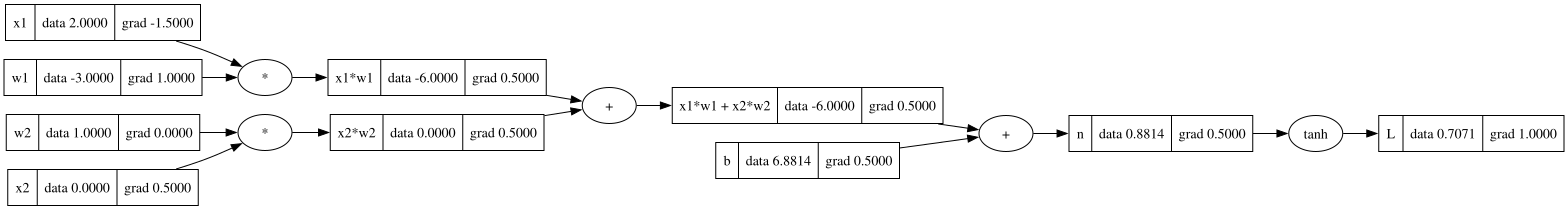

In [28]:
draw_dot(L)

In [ ]:
L.grad = 1.0
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x2.grad = 0.5
w2.grad= 0.0
x1.grad = -1.5
w1.grad = 1.0

In [19]:
L.grad = 1.0

In [21]:
L._backward()

In [23]:
n._backward()

In [25]:
x1w1x2w2._backward()

In [27]:
x1w1._backward()
x2w2._backward()